In [1]:
using Clapeyron, Metaheuristics, Printf

In [4]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
butanoicacid,88.11,3.4325,3.3489,224.1000,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,butanoicacid,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
butanoicacid,H,butanoicacid,e,2723.3000,0.0703
co2,H,co2,e,0,0
butanoicacid,H,co2,e,1361.65,0
butanoicacid,e,co2,H,1361.65,0
"""

model = PCSAFT(["co2", "butanoicacid"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 196.95654935264275; 196.95654935264275 224.1]
[2.785e-10 3.0669500000000005e-10; 3.0669500000000005e-10 3.3489e-10]
kij = -0.010000000000000009


In [5]:
function vle(model::EoSModel, x_co2::Float64)
    T = 313.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

vle (generic function with 1 method)

In [6]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 100.0,
        :upper   => 200.0,
        :guess   => 150.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 200.0, :param => :epsilon, :indices => (1, 2), :guess => 150.0, :lower => 100.0)

In [8]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vle_butanoicacid.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vle_butanoicacid.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vle_butanoicacid.csv
Initial objective value: 1.0e100


In [9]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([176.0932362233301], PCSAFT{BasicIdeal, Float64}("co2", "butanoicacid"))

In [10]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 176.0932362233301; 176.0932362233301 224.1]
[2.785e-10 3.0669500000000005e-10; 3.0669500000000005e-10 3.3489e-10]
kij = 0.09698779162137583


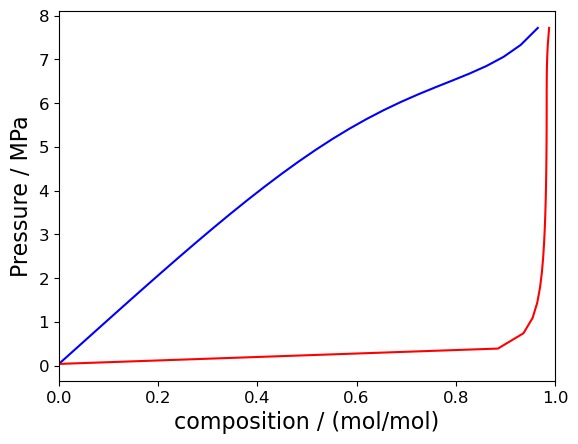

([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0], PyCall.PyObject[PyObject Text(0, -1.0, '−1'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 1.0, '1'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 3.0, '3'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 5.0, '5'), PyObject Text(0, 6.0, '6'), PyObject Text(0, 7.0, '7'), PyObject Text(0, 8.0, '8'), PyObject Text(0, 9.0, '9')])

In [14]:
import PyPlot; const plt = PyPlot

N    = 30
T    = 313.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [12]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [13]:
aard_p   = calculate_AAD(model_opt, "vle_propanoicacid.csv", vle)


=== AAD: vle_propanoicacid.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.1292      1009000.000000  1354913.913607  34.2828 
0.2505      1993000.000000  2563870.590717  28.6438 
0.3853      2995000.000000  3833177.531575  27.9859 
0.5291      3996000.000000  5019372.560588  25.6099 
0.7103      4995000.000000  6133383.383587  22.7905 
0.8224      5506000.000000  6651184.796005  20.7989 
0.9406      5997000.000000  7424005.303223  23.7953 
AARD = 26.2724%


26.272439467334618